# Fragment-expert RS-FFF checkpoint diagnostics

This notebook evaluates a fragment-expert checkpoint (`docs/fff_v2.md`). Point `CHECKPOINT` at a
run directory and every figure regenerates; the model is rebuilt from the config the checkpoint
carries, so there is nothing to keep in sync by hand.

The model in one paragraph. Every parameter is emitted by a per-composition expert evaluated on
**two slots** -- a fragment descriptor `h` and a cross-fragment descriptor `eta` that is
*identically zero* when a fragment is alone. So every quantity exists at two values,
`theta = P(h, eta)` and `theta_0 = P(h, 0)`, and the one-body sector reads only the second. There
are no neural pair corrections: the classical forms are evaluated as written, and what the network
supplies is their parameters.

The figures cover:

- correlation plots for each fitted energy component, monomer deformation energy, and total
  binding energy
- the per-fragment one-body residual, which is where a size-dependent offset in the deformation
  and binding panels would actually live
- **the isolated/environment split of every channel**: how much of each energy the model would
  produce if every fragment were described as though it were alone, and how much only appears
  because of what is nearby. This replaces the old classical/neural split, which no longer has
  a referent -- every channel is 100% classical now, and the question that took its place is
  where its *parameters* come from.
- molecular polarizability, dipole, and quadrupole moment correlations on the monomer anchor
- predicted parameter distributions at both evaluations, `theta_0` against `theta`, one figure
  per element
- predicted many-body contributions for each energy term
- force correlation for the total-energy gradient


In [5]:
%matplotlib inline

import os
import sys
from contextlib import contextmanager
from pathlib import Path
from types import SimpleNamespace

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rsfff.ff.many_body import mbe_dataset
from rsfff.ff.molecular_multipoles import fragment_multipoles, reference_multipoles
from rsfff.ff.multipole import spherical_to_cartesian_quadrupole
from rsfff.ff.units import BOHR_ANG, KJMOL_PER_HARTREE
from rsfff.mlip.heads import env_parameters
from rsfff.mlip.reference_states import AtomicStateReference
from rsfff.train.build_expert import build_expert_model
from rsfff.train.config import load_config
from rsfff.train.data import load_datasets, load_extxyz, load_reference_energies
from rsfff.train.loss import compute_forces
from rsfff.train.train_eem import resolve_device


In [6]:
# ---- Regeneration knobs ---------------------------------------------------------------
CHECKPOINT = "checkpoints/water_expert_full/best.pt"
# Only a fallback: a checkpoint embeds the full config it was trained under, stage
# overrides already applied, and that is what gets used. Reading a YAML instead let the
# notebook build a *different* model than the weights came from, and the failure looked
# like a bad fit rather than a mismatch.
CONFIG = "configs/water_expert.yaml"
DEVICE = "cpu"                  # CPU is stable for float64 plots; use "auto" if desired.
EVAL_SPLIT = "all"              # "all" or "validation"; validation is per-file here.
MAX_FRAMES_PER_CLUSTER = None    # e.g. 200 for quick iteration
BATCH_SIZE = 64
FORCE_FRAMES_PER_CLUSTER = 40    # forces need autograd; keep this modest for interactivity.
PARAMETER_FRAMES_PER_CLUSTER = 120
MBE_PER_CLUSTER = 40             # strongest frames per w3/w4/w5 cluster for MBE plots.
MBE_SORT_KEY = "int"
ISOLATED_SPECIES_REFERENCE = "data/isolated_species_wb97mv.extxyz"
REFERENCE_SPECIES = "H2O"
FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
# Figure names follow the checkpoint directory, so re-running this on another stage
# writes beside the old figures instead of over them.
FIGPREFIX = Path(CHECKPOINT).parent.name

# (channel, eda components summed to make its label, plot title). The label is a *tuple*
# because `induction` is fitted against `eda_pol + eda_ct` -- polarization and charge transfer
# are one term, so no single `eda_*` column supervises it. `_TARGETS` and
# `_INDUCTION_COMPONENTS` in rsfff.train.train_expert are what this mirrors.
ENERGY_TERMS = [
    ("onebody", ("fragment_energy",), "monomer deformation energy"),
    ("elst", ("cls_elec",), "frozen electrostatics"),
    ("pauli", ("mod_pauli",), "Pauli repulsion"),
    ("disp", ("disp",), "dispersion"),
    ("induction", ("pol", "ct"), "induction (pol + CT)"),
    ("total", ("energy",), "binding energy"),
]

PALETTE = {
    "w2": "#276ef1",
    "w3": "#1b998b",
    "w4": "#db6d00",
    "w5": "#7a4cc2",
}
ELEMENT = {1: "H", 8: "O"}
ELEMENT_COLOR = {1: "#276ef1", 8: "#d64545"}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})

In [7]:
def torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def stage_of(cfg):
    """Which stage this checkpoint's run directory belongs to, or None for a single fit."""
    for stage in cfg.stages:
        if cfg.run_name.endswith(f"_{stage.name}"):
            return stage.name
    return None


def load_expert_checkpoint(checkpoint=CHECKPOINT, device=DEVICE, config_fallback=CONFIG):
    """Rebuild the model from the checkpoint's **own** embedded config.

    A checkpoint stores the full `Config` it was trained under, stage overrides already applied,
    so nothing here reads a YAML and there is no stage to infer. That matters beyond
    convenience: reading the config from disk instead meant a notebook could silently build a
    *different* model than the weights came from, and the failure looked like a bad fit rather
    than a mismatch. `config_fallback` is only used for a checkpoint too old to carry one.

    `strict=True` on purpose -- a missing or unexpected tensor means the code has moved since
    the checkpoint was written, and loading anyway would plot a partly-initialized model.
    """
    state = torch_load(checkpoint)
    cfg = state.get("config")
    if cfg is None:
        cfg = load_config(config_fallback)
    torch.set_default_dtype(torch.float64 if cfg.dtype == "float64" else torch.float32)

    neighbor_types = state.get("neighbor_types")
    if neighbor_types is None:
        probe = load_datasets(cfg.data.path, dtype=torch.get_default_dtype())
        neighbor_types = probe.unique_atomic_numbers
    neighbor_types = tuple(int(z) for z in neighbor_types)

    reference_energies = load_reference_energies(
        cfg.data.reference_energies, neighbor_types
    ).to(torch.get_default_dtype())
    atomic_states = None
    if cfg.data.atomic_reference_states:
        atomic_states = AtomicStateReference.from_json(
            cfg.data.atomic_reference_states,
            neighbor_types,
            dtype=torch.get_default_dtype(),
        )
    model = build_expert_model(cfg, neighbor_types, reference_energies, atomic_states)
    model.load_state_dict(state["model_state"], strict=True)
    model.eval()
    resolved = torch.device("cpu" if device == "cpu" else resolve_device(device, cfg.dtype))
    model.to(resolved)
    return model, cfg, state, stage_of(cfg), resolved


@contextmanager
def environment_off(model):
    """Zero every environment-slot weight for the duration of the block.

    Inside it the model answers with `theta_0` everywhere: the parameters each fragment would
    have if it were alone in space. That is what makes an isolated/environment split of the
    *energy* possible -- run the batch twice and difference it -- and it is the notebook's
    version of the `env_*` columns the training log prints.

    It is also a live check of the model's central claim: the one-body sector must come out
    **bitwise identical** either way, because no `eta` reaches it. `collect_isolated_vs_env`
    asserts exactly that rather than trusting it.
    """
    saved = [(p, p.detach().clone()) for _name, p in env_parameters(model)]
    try:
        with torch.no_grad():
            for p, _ in saved:
                p.zero_()
        yield model
    finally:
        with torch.no_grad():
            for p, original in saved:
                p.copy_(original)


def cluster_tag(path):
    name = Path(path).name
    for token in name.replace("-", "_").split("_"):
        if token.startswith("w") and token[1:].isdigit():
            return token
    return Path(path).stem


def load_cluster_datasets(cfg):
    paths = cfg.data.path if isinstance(cfg.data.path, list) else [cfg.data.path]
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    return {cluster_tag(p): load_extxyz(p, dtype=dtype) for p in paths}


def reference_species_energy(path=ISOLATED_SPECIES_REFERENCE, species=REFERENCE_SPECIES):
    from ase.io import iread

    for atoms in iread(str(path), index=":"):
        if atoms.info.get("name") == species:
            return float(atoms.get_potential_energy())
    raise ValueError(f"no frame named {species!r} in {path}")


def frame_indices(dataset, cfg):
    n = len(dataset)
    idx = np.arange(n)
    if EVAL_SPLIT == "validation":
        rng = np.random.default_rng(cfg.data.seed)
        perm = rng.permutation(n)
        n_val = max(1, int(round(n * cfg.data.holdout_fraction)))
        idx = np.sort(perm[:n_val])
    elif EVAL_SPLIT != "all":
        raise ValueError("EVAL_SPLIT must be 'all' or 'validation'")
    if MAX_FRAMES_PER_CLUSTER is not None:
        idx = idx[:MAX_FRAMES_PER_CLUSTER]
    return idx.tolist()


def to_np(x):
    return x.detach().cpu().numpy()


def fragment_to_system(batch):
    if batch.fragment_to_batch is not None:
        return batch.fragment_to_batch
    f2b = batch.batch_idx.new_zeros(batch.n_fragments)
    return f2b.scatter_(0, batch.fragment_idx, batch.batch_idx)


def pool_fragments_to_frames(values, batch):
    f2b = fragment_to_system(batch)
    return values.new_zeros(batch.n_systems).index_add_(0, f2b, values)


In [8]:
model, cfg, state, stage_name, device = load_expert_checkpoint()
datasets = load_cluster_datasets(cfg)
anchor = load_extxyz(cfg.data.monomer_path, dtype=torch.get_default_dtype()) if cfg.data.monomer_path else None
h2o_reference_energy = reference_species_energy()

n_all = sum(p.numel() for p in model.parameters())
n_env = sum(p.numel() for _n, p in env_parameters(model))

print(f"checkpoint: {CHECKPOINT}")
print(f"stage: {stage_name or 'single'}    run_name: {cfg.run_name}")
print(f"epoch: {state.get('epoch', 'unknown')}    val_loss: {state.get('val_loss', float('nan')):.6g}")
print(f"device: {device}    dtype: {cfg.dtype}")
print(f"experts: {sorted(model.experts.experts)}   induction: {model.induction}")
print(f"parameters: {n_all}, of which {n_env} ({100 * n_env / n_all:.1f}%) in the environment slot")
print(f"env_penalty_weight: {cfg.expert.env_penalty_weight}")
print(f"{REFERENCE_SPECIES} reference: {h2o_reference_energy:.12f} Ha from {ISOLATED_SPECIES_REFERENCE}")
print("datasets:", {tag: len(ds) for tag, ds in datasets.items()})
if anchor is not None:
    print(f"monomer anchor: {len(anchor)} frames from {cfg.data.monomer_path}")


checkpoint: checkpoints/water_expert_full/best.pt
stage: full    run_name: water_expert_full
epoch: 79    val_loss: 142.073
device: cpu    dtype: float64
experts: ['H2O']   induction: True
parameters: 219156, of which 97088 (44.3%) in the environment slot
env_penalty_weight: 0.0
H2O reference: -76.433472976700 Ha from data/isolated_species_wb97mv.extxyz
datasets: {'w2': 2398, 'w3': 2392, 'w4': 2395, 'w5': 2394}
monomer anchor: 499 frames from data/wb97mv_tzvpd/h2o_wb97mv_tzvpd_pol.xyz


In [9]:
def fragments_per_frame(batch):
    f2b = fragment_to_system(batch)
    return torch.bincount(f2b, minlength=batch.n_systems).to(batch.positions.dtype)


def collect_energy_predictions(model, datasets, cfg, device, monomer_ref_energy, batch_size=BATCH_SIZE):
    rows = {term: {"ref": [], "pred": [], "tag": []} for term, _, _ in ENERGY_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)

            for term, target, _label in ENERGY_TERMS:
                if term == "total":
                    n_frag = fragments_per_frame(batch)
                    pred = out.energy - monomer_ref_energy * n_frag
                    ref = batch.energy - monomer_ref_energy * n_frag
                elif term == "onebody":
                    if batch.fragment_energy is None:
                        continue
                    pred = pool_fragments_to_frames(out.fragment_energy - monomer_ref_energy, batch)
                    ref = pool_fragments_to_frames(batch.fragment_energy - monomer_ref_energy, batch)
                else:
                    # `target` is a tuple: induction's label is the sum of two EDA columns.
                    # Skip the channel unless the model has it *and* every component of its
                    # label is on the batch -- a frozen-stage checkpoint has no `induction`
                    # in `out.interaction`, which is what drops the panel rather than an error.
                    if term not in out.interaction or batch.eda is None:
                        continue
                    if any(k not in batch.eda for k in target):
                        continue
                    pred = out.interaction[term]
                    ref = sum(batch.eda[k] for k in target)
                rows[term]["pred"].append(to_np(pred) * KJMOL_PER_HARTREE)
                rows[term]["ref"].append(to_np(ref) * KJMOL_PER_HARTREE)
                rows[term]["tag"].extend([tag] * len(pred))
    packed = {}
    for term, data in rows.items():
        if data["pred"]:
            packed[term] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "tag": np.asarray(data["tag"]),
            }
    return packed


def metrics(ref, pred):
    err = pred - ref
    if len(ref) > 1 and np.std(ref) > 0 and np.std(pred) > 0:
        r2 = float(np.corrcoef(ref, pred)[0, 1] ** 2)
    else:
        r2 = np.nan
    return float(np.abs(err).mean()), float(np.sqrt(np.mean(err ** 2))), r2


energy = collect_energy_predictions(model, datasets, cfg, device, h2o_reference_energy)
print(f"{'term':<12}{'n':>8}{'MAE':>12}{'RMSE':>12}{'R2':>10}")
for term, _target, label in ENERGY_TERMS:
    if term not in energy:
        continue
    mae, rmse, r2 = metrics(energy[term]["ref"], energy[term]["pred"])
    print(f"{term:<12}{len(energy[term]['ref']):>8}{mae:>12.4f}{rmse:>12.4f}{r2:>10.5f}  {label}")

term               n         MAE        RMSE        R2
onebody         9579      0.5467      0.5900   0.99958  monomer deformation energy
elst            9579      0.7456      1.0908   0.99950  frozen electrostatics
pauli           9579      0.4397      0.6335   0.99990  Pauli repulsion
disp            9579      0.2499      0.3341   0.99925  dispersion
induction       9579      0.3083      0.4387   0.99962  induction (pol + CT)
total           9579      0.9579      1.3161   0.99710  binding energy


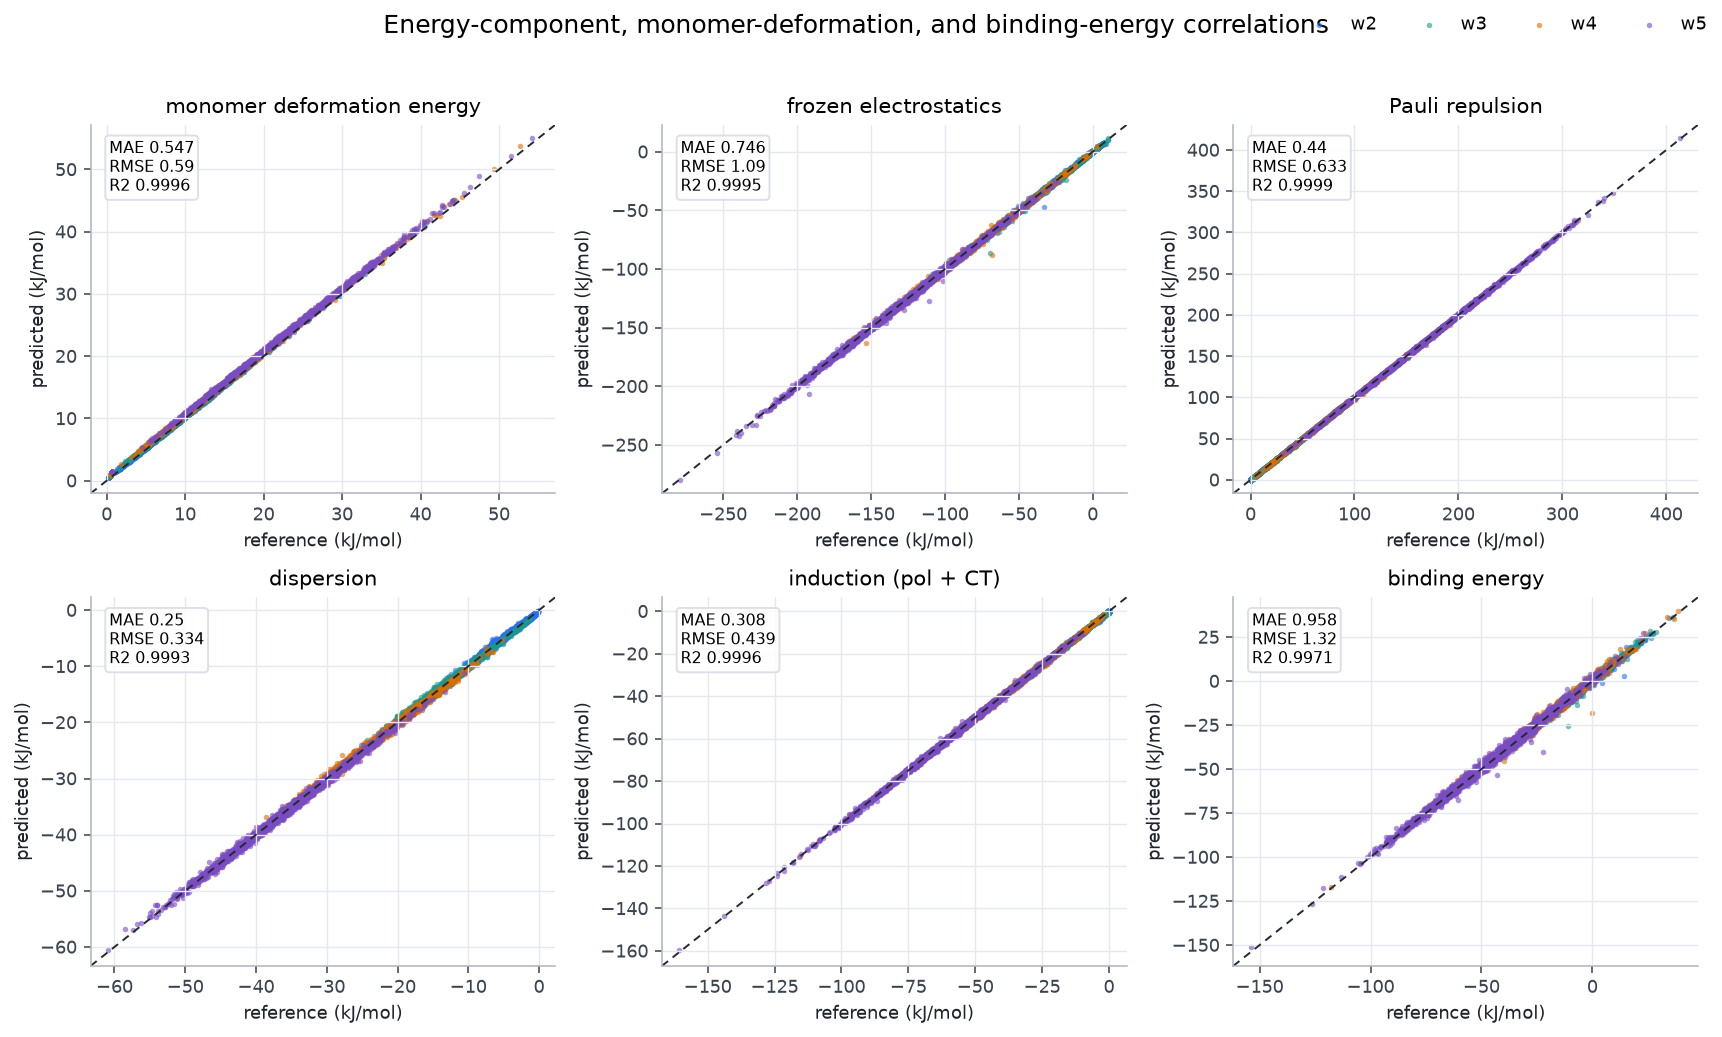

In [10]:
def plot_parity_grid(data, labels, *, title, unit, path=None, ncols=3):
    keys = [k for k, _ in labels if k in data]
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, key in zip(axes.ravel(), keys):
        ax.set_visible(True)
        d = data[key]
        ref, pred, tags = d["ref"], d["pred"], d.get("tag")
        lo = min(np.min(ref), np.min(pred))
        hi = max(np.max(ref), np.max(pred))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0, ls=(0, (4, 3)))
        if tags is None:
            ax.scatter(ref, pred, s=8, alpha=0.65, lw=0, color="#276ef1")
        else:
            for tag in sorted(set(tags)):
                m = tags == tag
                ax.scatter(ref[m], pred[m], s=8, alpha=0.6, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(dict(labels)[key])
        ax.set_xlabel(f"reference ({unit})")
        ax.set_ylabel(f"predicted ({unit})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    handles, labels_ = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="upper right", frameon=False, ncol=len(handles))
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

energy_labels = [(term, label) for term, _target, label in ENERGY_TERMS]
fig = plot_parity_grid(
    energy,
    energy_labels,
    title="Energy-component, monomer-deformation, and binding-energy correlations",
    unit="kJ/mol",
    path=FIGDIR / f"{FIGPREFIX}_energy_correlations.png",
)
plt.show()

## Where the size-dependent offset comes from

The deformation-energy and binding-energy panels above are pooled **per frame**, so a
constant per-*fragment* error is drawn as `n_fragments` times itself: a pure constant looks
like a size-dependent offset. This section separates the two. It reports the one-body
residual per fragment, which is where the constant actually lives, and then replots the two
pooled panels with that single number removed.

Read it as: `bias` is the constant, `MAE - |bias|` is the geometry-dependent part that the
model genuinely gets wrong, and `n_frag * bias` is the offset the pooled plots show.

A constant here is worth watching for a specific reason. The bonding head has no free-atom
anchoring, so its readout bias *is* the one-body constant and the fit can reach it directly.
In the model this replaced that direction was cancelled by the anchoring, and the result was
a measured -5.23 kJ/mol per fragment that nothing in the loss could remove cheaply.

In [11]:
def onebody_residual_by_fragment(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment `fragment_energy` residual, kept per fragment rather than per frame.

    `collect_energy_predictions` pools fragments to frames because that is the scale the
    binding energy lives on. That pooling is also what turns a constant into a slope, so this
    deliberately does not do it -- the per-fragment residual is the quantity a constant offset
    is constant in.
    """
    rows = {}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        err, n_frag = [], []
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            e = (out.fragment_energy - batch.fragment_energy) * KJMOL_PER_HARTREE
            err.append(to_np(e))
            n_frag.append(to_np(fragments_per_frame(batch)))
        rows[tag] = {"err": np.concatenate(err), "n_frag": np.concatenate(n_frag)}
    return rows


onebody_res = onebody_residual_by_fragment(model, datasets, cfg, device)
pooled = np.concatenate([d["err"] for d in onebody_res.values()])
BIAS = float(pooled.mean())

print("per-fragment one-body residual (kJ/mol)")
print(f"{'cluster':>8}{'n_frag':>8}{'bias':>10}{'MAE':>10}{'std':>10}{'frame offset':>14}")
for tag in sorted(onebody_res):
    d = onebody_res[tag]
    e, nf = d["err"], float(d["n_frag"][0])
    print(f"{tag:>8}{nf:>8.0f}{e.mean():>+10.4f}{np.abs(e).mean():>10.4f}"
          f"{e.std():>10.4f}{nf * e.mean():>+14.4f}")
print(f"\npooled over {len(pooled)} fragments: bias {BIAS:+.4f}  "
      f"MAE {np.abs(pooled).mean():.4f}  std {pooled.std():.4f}")
print(f"with the constant removed:      MAE {np.abs(pooled - BIAS).mean():.4f}  "
      f"RMSE {np.sqrt(((pooled - BIAS) ** 2).mean()):.4f}")

per-fragment one-body residual (kJ/mol)
 cluster  n_frag      bias       MAE       std  frame offset
      w2       2   +0.1555    0.1561    0.0690       +0.3110
      w3       3   +0.1570    0.1575    0.0668       +0.4710
      w4       4   +0.1568    0.1575    0.0663       +0.6273
      w5       5   +0.1555    0.1561    0.0663       +0.7776

pooled over 33522 fragments: bias +0.1562  MAE 0.1568  std 0.0668
with the constant removed:      MAE 0.0435  RMSE 0.0668


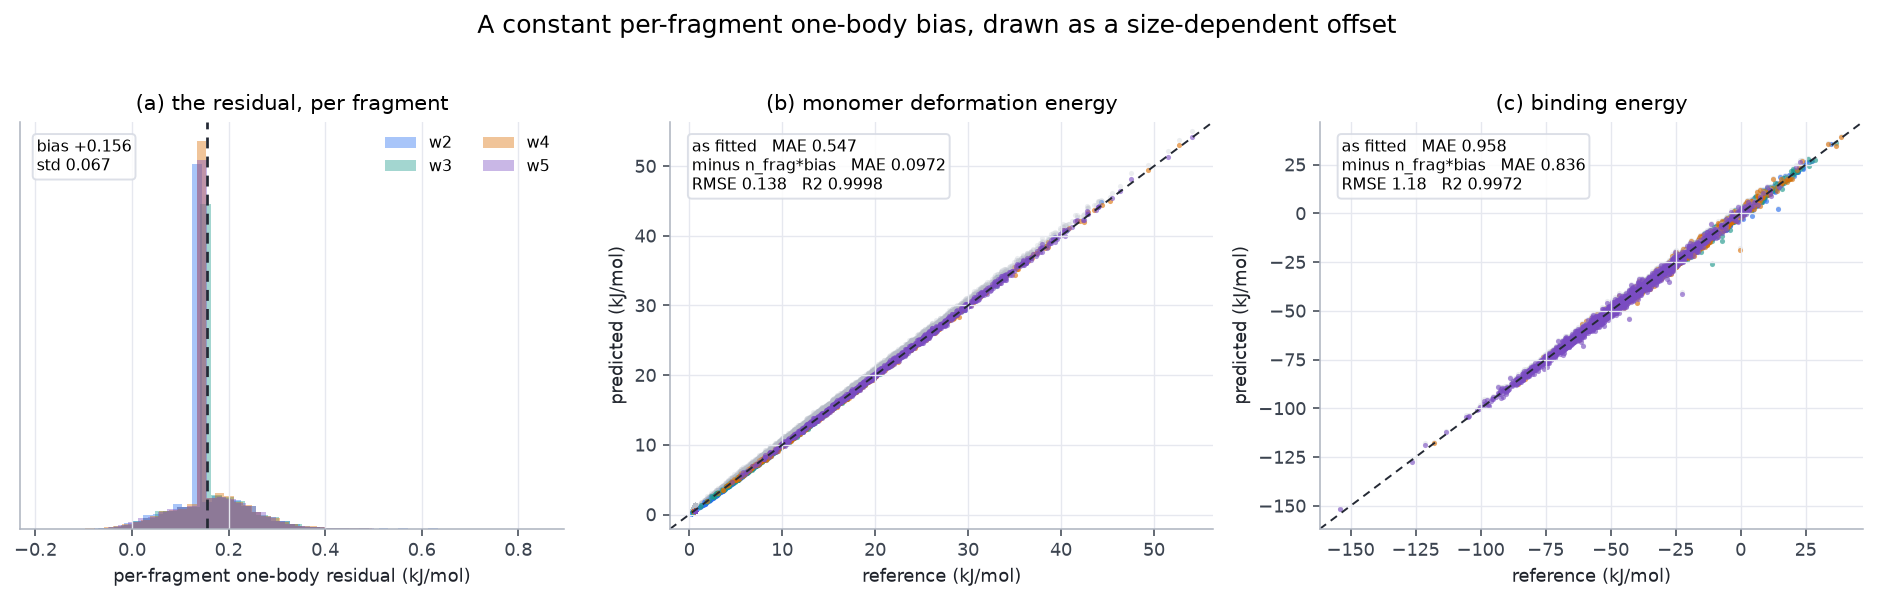

In [12]:
def plot_onebody_offset(onebody_res, energy, bias, path=None):
    """Left: the residual is a constant. Right/centre: the pooled panels with it removed."""
    tags = sorted(onebody_res)
    per_tag_n_frag = {t: float(onebody_res[t]["n_frag"][0]) for t in tags}
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))

    ax = axes[0]
    for tag in tags:
        e = onebody_res[tag]["err"]
        ax.hist(e, bins=40, density=True, histtype="stepfilled", alpha=0.4,
                color=PALETTE.get(tag, "#555"), label=tag)
    ax.axvline(bias, color="#242934", lw=1.4, ls=(0, (4, 3)))
    # In axes coordinates, not at the line: the distribution is sharply peaked right where the
    # line falls, so anchoring the label to the data would drop it on top of the spike.
    ax.text(0.03, 0.96, f"bias {bias:+.3f}\nstd {np.concatenate([onebody_res[t]['err'] for t in tags]).std():.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("per-fragment one-body residual (kJ/mol)")
    ax.set_yticks([])
    ax.set_title("(a) the residual, per fragment")
    ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")

    # The pooled panels, before and after removing n_frag * bias. `energy` was collected with
    # the same frame ordering, so `n_frag` lines up term by term.
    for ax, term, label in ((axes[1], "onebody", "monomer deformation energy"),
                            (axes[2], "total", "binding energy")):
        if term not in energy:
            ax.set_visible(False)
            continue
        d = energy[term]
        ref, pred, tag_arr = d["ref"], d["pred"], d["tag"]
        # Fragment count per frame, looked up by cluster tag rather than by position, so this
        # does not depend on the two collectors having iterated the datasets in the same order.
        n_frag = np.array([per_tag_n_frag[t] for t in tag_arr])
        corrected = pred - n_frag * bias
        lo = min(ref.min(), corrected.min())
        hi = max(ref.max(), corrected.max())
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0,
                ls=(0, (4, 3)))
        for tag in tags:
            m = tag_arr == tag
            ax.scatter(ref[m], pred[m], s=7, alpha=0.25, lw=0, color="#b6bcc7")
            ax.scatter(ref[m], corrected[m], s=7, alpha=0.6, lw=0,
                       color=PALETTE.get(tag, "#555"), label=tag)
        mae0, _, _ = metrics(ref, pred)
        mae1, rmse1, r21 = metrics(ref, corrected)
        ax.text(0.04, 0.96,
                f"as fitted   MAE {mae0:.3g}\nminus n_frag*bias   MAE {mae1:.3g}\n"
                f"RMSE {rmse1:.3g}   R2 {r21:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3",
                      "alpha": 0.85})
        ax.set_xlabel("reference (kJ/mol)")
        ax.set_ylabel("predicted (kJ/mol)")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"({'b' if term == 'onebody' else 'c'}) {label}")

    fig.suptitle("A constant per-fragment one-body bias, drawn as a size-dependent offset",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_onebody_offset(onebody_res, energy, BIAS,
                          path=FIGDIR / f"{FIGPREFIX}_onebody_offset.png")
plt.show()

## Isolated parameters versus the environment

Every channel here is `gate * e_classical`, with no neural term added on top -- so the old
classical/neural split has no referent. The question that replaced it is where the *parameters*
come from.

Each parameter exists at two values: `theta_0 = P(h, 0)`, what the expert says about a fragment
described as though it were alone, and `theta = P(h, eta)`, what it says in the medium. Running a
batch twice -- once with every environment weight zeroed -- splits each channel's energy the same
way. `iso` is what the model would produce with every fragment treated as isolated; `env` is what
only appears because of what is nearby.

That is the effective many-body content, and it is where it *should* be. `eda_cls_elec` is the
Coulomb interaction between superimposed frozen monomer densities, which is rigorously pairwise,
so its parameters read `theta_0` and its `env` bar must be zero. The modified Pauli term
antisymmetrizes the product of all the monomer densities and the dispersion is a supersystem
difference -- neither is pairwise, and a quenched `C6` is what that looks like here.

**The one-body panel is a live check, not a plot.** `fragment_energy` reads `theta_0` everywhere,
so it must be bitwise identical between the two runs. The cell asserts it.

Induction keeps a third number. Its bonding contribution is `E_bond` read at the relaxed state
*and* at the in-medium parameters, and the parameter half of that -- `energy_bond_ind -
energy_bond_ind_iso` -- is a route to the label needing no charge to move and no multipole to
relax. In an earlier two-level model it was 100% of the `ct` channel while every printed metric
looked healthy. It is reported, not penalised: some of it is real charge transfer, and the size is
what says how much.

Everything is normalised **per fragment** so the four cluster sizes are directly comparable. The
one-body bucket gets its own axis because it is two orders of magnitude larger; `E_0`, the fixed
atomic reference, is left out since it is neither fitted nor environment-dependent.


In [13]:
SPLIT_TERMS = [
    ("elst", "frozen\nelectrostatics"),
    ("pauli", "Pauli\nrepulsion"),
    ("disp", "dispersion"),
    ("induction", "induction\n(pol + CT)"),
]
ISO_COLOR = "#3c4450"
ENV_COLOR = "#e07a3f"


def collect_isolated_vs_env(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment isolated and environment halves of every channel.

    Two forwards per batch: one as trained, one inside `environment_off`. The difference is the
    energy that exists only because of the surroundings.

    The one-body sector is asserted rather than plotted -- it reads `theta_0` whatever the
    environment weights are, so the two runs must agree bitwise. If this ever raises, the
    routing has a leak and every isolated number in the notebook is meaningless.
    """
    rows = {"tag": []}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
                with environment_off(model):
                    iso = model(batch)
            n_frag = fragments_per_frame(batch)

            def per_fragment(x):
                return to_np(x / n_frag) * KJMOL_PER_HARTREE

            assert torch.equal(out.fragment_energy, iso.fragment_energy), (
                "fragment_energy moved when the environment weights were zeroed -- the "
                "one-body sector is reading eta somewhere it must not"
            )

            for name in out.interaction:
                rows.setdefault(f"{name}|iso", []).append(per_fragment(iso.interaction[name]))
                rows.setdefault(f"{name}|env", []).append(
                    per_fragment(out.interaction[name] - iso.interaction[name])
                )

            # The parameter half of the induction correction: `E_bond` at the same relaxed
            # electronic state, read at `theta` instead of `theta_0`. Nothing consumes
            # `energy_bond_ind_iso`; it exists only to make this measurable.
            if out.energy_bond_ind is not None and out.energy_bond_ind_iso is not None:
                swap = pool_fragments_to_frames(
                    out.energy_bond_ind - out.energy_bond_ind_iso, batch
                )
                rows.setdefault("induction|swap", []).append(per_fragment(swap))

            intra = out.is_intra.to(out.r.dtype)
            pair_batch = batch.batch_idx[out.pair_index[0]]

            def pool_pairs(x):
                return x.new_zeros(batch.n_systems).index_add_(0, pair_batch, x)

            rows.setdefault("onebody|internal", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_internal, batch)))
            rows.setdefault("onebody|intra", []).append(
                per_fragment(pool_pairs(intra * sum(out.e_pair.values()))))
            rows.setdefault("onebody|bond", []).append(
                per_fragment(pool_fragments_to_frames(out.energy_bond, batch)))
            rows["tag"].extend([tag] * batch.n_systems)
    return {k: (np.asarray(v) if k == "tag" else np.concatenate(v)) for k, v in rows.items()}


split = collect_isolated_vs_env(model, datasets, cfg, device)
print(f"{'component':<12}{'isolated':>12}{'environment':>13}{'env share':>11}"
      f"{'param half':>12}{'/env':>9}   (kJ/mol per fragment)")
for key, _label in SPLIT_TERMS:
    if f"{key}|iso" not in split:
        continue
    iso, env = split[f"{key}|iso"], split[f"{key}|env"]
    share = np.abs(env).mean() / max(np.abs(iso).mean() + np.abs(env).mean(), 1e-30)
    swap = split.get(f"{key}|swap")
    if swap is None:
        tail = f"{'-':>12}{'-':>9}"
    else:
        frac = np.abs(swap).mean() / max(np.abs(env).mean(), 1e-30)
        tail = f"{swap.mean():>+12.4f}{100 * frac:>8.1f}%"
    print(f"{key:<12}{iso.mean():>+12.4f}{env.mean():>+13.4f}{100 * share:>10.1f}%{tail}")
print(f"\n{'onebody':<12}"
      f"internal {split['onebody|internal'].mean():>+10.3f}   "
      f"intra classical {split['onebody|intra'].mean():>+8.3f}   "
      f"bond {split['onebody|bond'].mean():>+10.3f}")
print("environment share of the one-body sector: 0.0% exactly, by construction (asserted above)")


component       isolated  environment  env share  param half     /env   (kJ/mol per fragment)
elst            -21.4658      +0.0000       0.0%           -        -
pauli           +28.5717      -1.4953       5.0%           -        -
disp             -5.9267      +0.2128       3.5%           -        -
induction        -2.7643      -6.1767      69.1%     -2.2130    35.8%

onebody     internal   -284.482   intra classical   +0.788   bond   -677.947
environment share of the one-body sector: 0.0% exactly, by construction (asserted above)


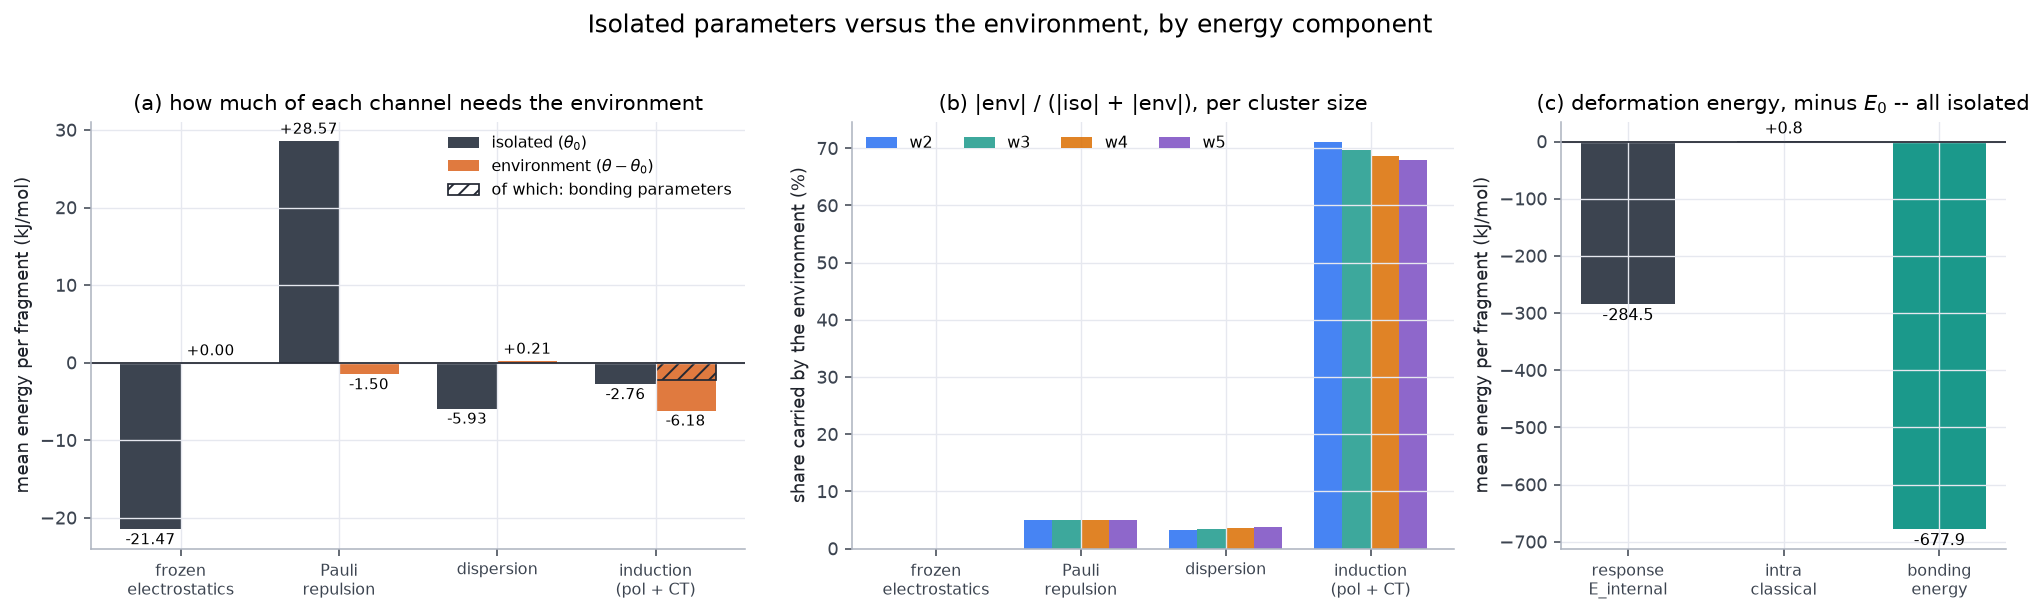

In [14]:
def plot_isolated_vs_env(split, path=None):
    tags = [t for t in ("w2", "w3", "w4", "w5") if t in set(split["tag"])]
    terms = [(k, l) for k, l in SPLIT_TERMS if f"{k}|iso" in split]
    x = np.arange(len(terms))
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                             gridspec_kw={"width_ratios": [1.25, 1.15, 0.85]})

    ax = axes[0]
    width = 0.38
    iso = [split[f"{k}|iso"].mean() for k, _ in terms]
    env = [split[f"{k}|env"].mean() for k, _ in terms]
    ax.bar(x - width / 2, iso, width, color=ISO_COLOR, label=r"isolated ($\theta_0$)")
    ax.bar(x + width / 2, env, width, color=ENV_COLOR, label=r"environment ($\theta-\theta_0$)")
    # Drawn over the environment bar rather than beside it, because it is a *part* of it: the
    # share carried by the bonding parameters rather than by a relaxation of the multipoles.
    swap_drawn = False
    for xi, (k, _label) in enumerate(terms):
        if f"{k}|swap" not in split:
            continue
        ax.bar(xi + width / 2, split[f"{k}|swap"].mean(), width, facecolor="none",
               edgecolor="#242934", hatch="///", lw=0.9,
               label=None if swap_drawn else "of which: bonding parameters")
        swap_drawn = True
    for xi, (a, b) in enumerate(zip(iso, env)):
        for dx, v in ((-width / 2, a), (width / 2, b)):
            ax.annotate(f"{v:+.2f}", (xi + dx, v), ha="center", fontsize=7.5,
                        va="bottom" if v >= 0 else "top",
                        xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    ax.set_title("(a) how much of each channel needs the environment")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    width = 0.78 / max(1, len(tags))
    for j, tag in enumerate(tags):
        m = split["tag"] == tag
        share = []
        for k, _ in terms:
            a = np.abs(split[f"{k}|iso"][m]).mean()
            b = np.abs(split[f"{k}|env"][m]).mean()
            share.append(100.0 * b / max(a + b, 1e-30))
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, share, width,
               color=PALETTE.get(tag, "#555"), alpha=0.85, label=tag)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("share carried by the environment (%)")
    # A share that *grows* with cluster size is the signature of real many-body physics; one
    # that is already large on w2, where there is none, is the environment slot doing two-body
    # work the isolated parameters should be doing.
    ax.set_title("(b) |env| / (|iso| + |env|), per cluster size")
    ax.legend(frameon=False, fontsize=8, ncol=len(tags))

    ax = axes[2]
    pieces = [("onebody|internal", "response\nE_internal", ISO_COLOR),
              ("onebody|intra", "intra\nclassical", "#7f8794"),
              ("onebody|bond", "bonding\nenergy", "#1b998b")]
    values = [split[k].mean() for k, _, _ in pieces]
    ax.bar(np.arange(len(pieces)), values, 0.6, color=[c for _, _, c in pieces])
    for i, v in enumerate(values):
        ax.annotate(f"{v:+.1f}", (i, v), ha="center", fontsize=8,
                    va="bottom" if v >= 0 else "top",
                    xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(np.arange(len(pieces)))
    ax.set_xticklabels([l for _, l, _ in pieces], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    # No environment bar here, and that is the point: every term in this panel reads theta_0.
    ax.set_title("(c) deformation energy, minus $E_0$ -- all isolated")

    fig.suptitle("Isolated parameters versus the environment, by energy component",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_isolated_vs_env(split, path=FIGDIR / f"{FIGPREFIX}_isolated_vs_environment.png")
plt.show()


In [15]:
def collect_response_properties(model, anchor, device, batch_size=BATCH_SIZE):
    if anchor is None:
        raise ValueError("cfg.data.monomer_path is not set, so no polarizability/multipole anchor is available")
    chunks = {
        "polarizability": {"ref": [], "pred": [], "component": []},
        "dipole": {"ref": [], "pred": [], "component": []},
        "quadrupole": {"ref": [], "pred": [], "component": []},
    }
    tri = np.triu_indices(3)
    alpha_labels = np.array(["xx", "xy", "xz", "yy", "yz", "zz"])
    dip_labels = np.array(["x", "y", "z"])
    quad_labels = alpha_labels

    for start in range(0, len(anchor), batch_size):
        batch = anchor.flat_batch(range(start, min(start + batch_size, len(anchor)))).to(device)
        with torch.no_grad():
            # `with_induction=False` for the same reason the training anchor uses it: a
            # lone fragment still relaxes against its own field, where ALMO-EDA reports
            # exactly zero. The polarizability and multipoles come off the frozen solve
            # either way, so this only removes an artifact and a coupled solve.
            out = model(batch, with_polarizability=True, with_induction=False)
        if out.polarizability is not None and batch.polarizability is not None:
            pred_a = to_np(out.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            ref_a = to_np(batch.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            chunks["polarizability"]["pred"].append(pred_a.ravel())
            chunks["polarizability"]["ref"].append(ref_a.ravel())
            chunks["polarizability"]["component"].extend(np.tile(alpha_labels, pred_a.shape[0]))

        if batch.fragment_dipole is not None and batch.fragment_second_moment is not None:
            quad_c = None if out.quad_s is None else spherical_to_cartesian_quadrupole(out.quad_s)
            frag_q = batch.fragment_charge if batch.fragment_charge is not None else batch.positions.new_zeros(batch.n_fragments)
            pred_d, pred_q = fragment_multipoles(
                out.charges, batch.positions, batch.atomic_numbers, batch.fragment_idx,
                batch.n_fragments, frag_q, out.mu, quad_c,
            )
            ref_d, ref_q = reference_multipoles(
                batch.fragment_dipole, batch.fragment_second_moment, batch.positions,
                batch.atomic_numbers, batch.fragment_idx, batch.n_fragments, frag_q,
            )
            pred_d, ref_d = to_np(pred_d), to_np(ref_d)
            pred_q, ref_q = to_np(pred_q)[:, tri[0], tri[1]], to_np(ref_q)[:, tri[0], tri[1]]
            chunks["dipole"]["pred"].append(pred_d.ravel())
            chunks["dipole"]["ref"].append(ref_d.ravel())
            chunks["dipole"]["component"].extend(np.tile(dip_labels, pred_d.shape[0]))
            chunks["quadrupole"]["pred"].append(pred_q.ravel())
            chunks["quadrupole"]["ref"].append(ref_q.ravel())
            chunks["quadrupole"]["component"].extend(np.tile(quad_labels, pred_q.shape[0]))

    packed = {}
    for key, data in chunks.items():
        if data["pred"]:
            packed[key] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "component": np.asarray(data["component"]),
            }
    return packed


properties = collect_response_properties(model, anchor, device) if anchor is not None else {}
for key, d in properties.items():
    mae, rmse, r2 = metrics(d["ref"], d["pred"])
    print(f"{key:<16} n={len(d['ref']):<6} MAE={mae:.5g} RMSE={rmse:.5g} R2={r2:.5f}")

polarizability   n=2994   MAE=0.065366 RMSE=0.13348 R2=0.99928
dipole           n=1497   MAE=0.0087153 RMSE=0.015053 R2=0.99829
quadrupole       n=2994   MAE=0.045884 RMSE=0.083779 R2=0.99453


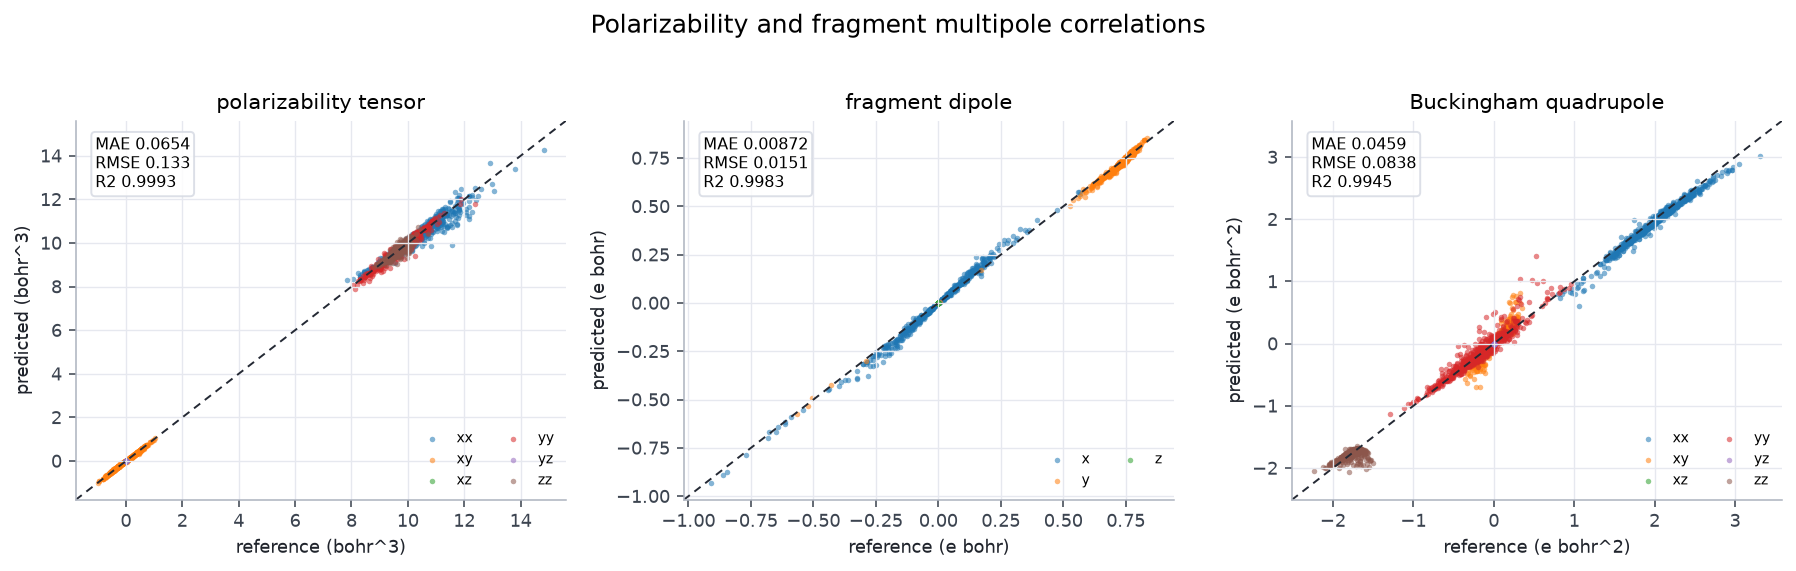

In [16]:
def plot_property_correlations(properties, path=None):
    labels = {
        "polarizability": ("polarizability tensor", "bohr^3"),
        "dipole": ("fragment dipole", "e bohr"),
        "quadrupole": ("Buckingham quadrupole", "e bohr^2"),
    }
    keys = [k for k in labels if k in properties]
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.9), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, key in zip(axes.ravel(), keys):
        d = properties[key]
        ref, pred, comp = d["ref"], d["pred"], d["component"]
        lo = min(ref.min(), pred.min())
        hi = max(ref.max(), pred.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
        for i, c in enumerate(sorted(set(comp))):
            m = comp == c
            ax.scatter(ref[m], pred[m], s=8, alpha=0.55, lw=0, color=colors[i % len(colors)], label=c)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(labels[key][0])
        ax.set_xlabel(f"reference ({labels[key][1]})")
        ax.set_ylabel(f"predicted ({labels[key][1]})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.suptitle("Polarizability and fragment multipole correlations", y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

if properties:
    fig = plot_property_correlations(properties, path=FIGDIR / f"{FIGPREFIX}_response_property_correlations.png")
    plt.show()

In [17]:
def slot_parameters(model, batch):
    """Every per-atom parameter at **both** evaluations: `theta_0` and `theta`.

    `model.slots` returns the pair of descriptors; `isolated()` is the fragment block alone and
    `joined()` is `[h | eta]`. Handing a head the narrow one is what makes its answer the
    isolated-fragment parameter -- there is no environment column in the arithmetic at all, so
    it is exact rather than approximately environment-free.
    """
    expert = model.experts.only
    slots = model.slots(batch, batch.fragment_idx)
    iso, joined = slots.isolated(), slots.joined()

    def heads(feats):
        c6, b_disp = expert.disp_params(feats.inv_feats, feats.species_idx)
        q_p, b_p, mu_p, quad_p = expert.pauli_params(
            feats.inv_feats, feats.species_idx, feats.vec_feats, feats.equiv_feats
        )
        r0, alpha = expert.range_heads(feats.inv_feats, feats.species_idx)
        return {
            "c6": c6, "b_disp": b_disp, "q_pauli": q_p, "b_pauli": b_p,
            "mu_pauli": mu_p.norm(dim=-1) if mu_p is not None else torch.zeros_like(c6),
            "quad_pauli": quad_p.norm(dim=-1) if quad_p is not None else torch.zeros_like(c6),
            "r0_elst": r0["elst"], "r0_pauli": r0["pauli"], "r0_disp": r0["disp"],
        }, {f"alpha_{k}": float(v) for k, v in alpha.items()}

    joined_p, scalars = heads(joined)
    iso_p, _ = heads(iso)
    return iso_p, joined_p, scalars, slots


#: Parameters that have both an isolated and an in-medium value. The response-sector quantities
#: (chi, eta, z, b, cquad) come off the frozen solve, which is fragment-confined by
#: construction, so they have one value and appear without an `_iso` twin.
DUAL_KEYS = ["c6", "b_disp", "q_pauli", "b_pauli", "mu_pauli", "quad_pauli",
             "r0_elst", "r0_pauli", "r0_disp"]


def collect_atom_parameters(model, datasets, device, n_frames=PARAMETER_FRAMES_PER_CLUSTER, batch_size=BATCH_SIZE):
    keys = ["tag", "Z", "q", "chi", "eta", "z_pen", "b_pen", "cquad", "env_norm"]
    keys += DUAL_KEYS + [f"{k}_iso" for k in DUAL_KEYS]
    parts = {k: [] for k in keys}
    scalars = {}
    for tag, ds in datasets.items():
        take = min(n_frames, len(ds))
        for start in range(0, take, batch_size):
            batch = ds.flat_batch(range(start, min(start + batch_size, take))).to(device)
            with torch.no_grad():
                out = model(batch)
                iso_p, joined_p, alphas, slots = slot_parameters(model, batch)
            scalars.update(alphas)
            n = len(batch.atomic_numbers)
            parts["tag"].extend([tag] * n)
            parts["Z"].append(to_np(batch.atomic_numbers))
            parts["q"].append(to_np(out.response.charges))
            parts["chi"].append(to_np(out.response.chi))
            parts["eta"].append(to_np(out.response.eta))
            parts["z_pen"].append(to_np(out.response.z))
            parts["b_pen"].append(to_np(out.response.b))
            cquad = out.response.cquad
            if cquad is not None and cquad.dim() > 1:
                cquad = cquad.reshape(cquad.shape[0], -1).norm(dim=-1)
            parts["cquad"].append(to_np(cquad) if cquad is not None else np.zeros(n))
            # ||eta|| per atom. Unlike the environment residual this replaced, it is a property
            # of the geometry rather than of the weights, so it cannot be flattened by decay --
            # a zero here means the atom has no neighbour inside the feature cutoff.
            parts["env_norm"].append(to_np(out.env_norm))
            for k in DUAL_KEYS:
                parts[k].append(to_np(joined_p[k]))
                parts[f"{k}_iso"].append(to_np(iso_p[k]))
    packed = {k: (np.asarray(v) if k == "tag" else np.concatenate(v)) for k, v in parts.items()}
    packed.update(scalars)
    return packed


params = collect_atom_parameters(model, datasets, device)
print(f"parameter atoms: {len(params['Z'])}")
for key in ("alpha_elst", "alpha_pauli", "alpha_disp"):
    print(f"{key}: {params[key]:.4g} 1/A")

print(f"\n{'parameter':<12}{'element':>8}{'isolated':>12}{'in medium':>12}{'mean |d log|':>14}")
for key in DUAL_KEYS:
    for z in sorted(set(params["Z"])):
        m = params["Z"] == z
        a, b = params[f"{key}_iso"][m], params[key][m]
        if np.allclose(a, b):
            continue
        shift = np.abs(np.log(np.abs(b) + 1e-30) - np.log(np.abs(a) + 1e-30)).mean()
        print(f"{key:<12}{ELEMENT.get(int(z), z):>8}{a.mean():>12.4g}{b.mean():>12.4g}{shift:>14.5f}")


parameter atoms: 5040
alpha_elst: 36.6 1/A
alpha_pauli: 36.6 1/A
alpha_disp: 36.58 1/A

parameter    element    isolated   in medium  mean |d log|
c6                 H       2.292        2.22       0.04405
c6                 O       30.87       31.13       0.05223
q_pauli            H      0.4723      0.4737       0.00294
q_pauli            O       6.273       6.272       0.00141
mu_pauli           H     0.06832     0.04936       0.52473
mu_pauli           O      0.3794      0.3198       0.21280
quad_pauli         H      0.1034     0.09164       0.15242
quad_pauli         O       1.641       1.522       0.08809


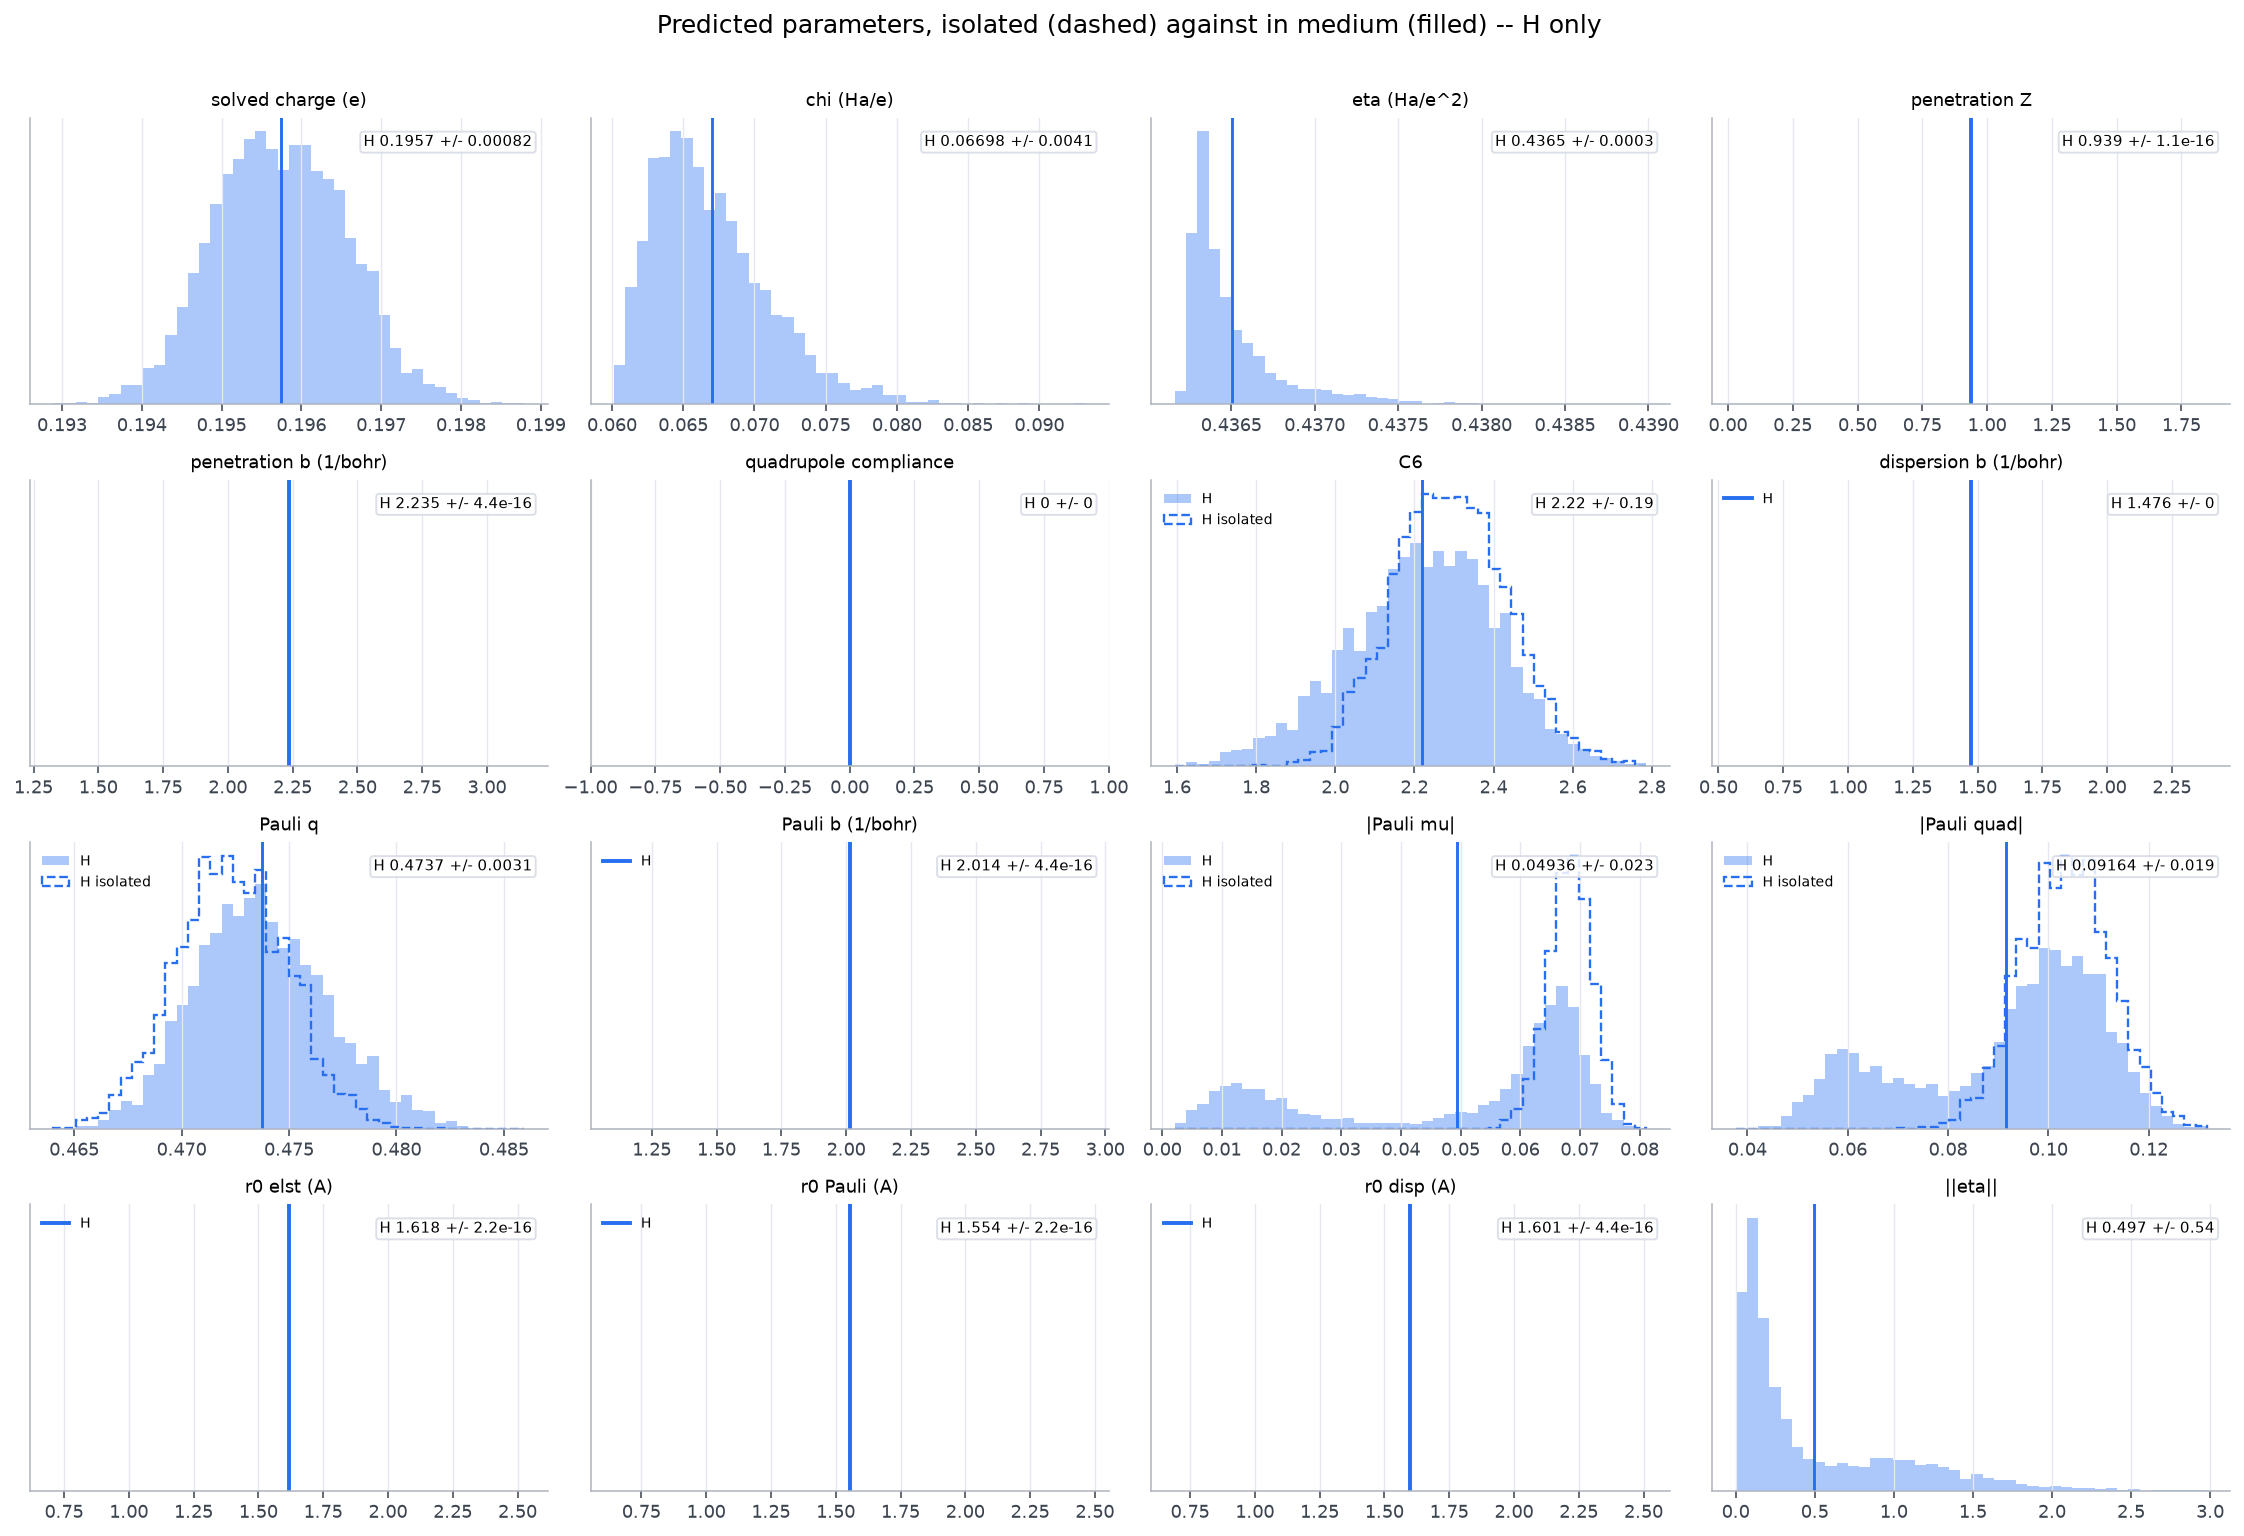

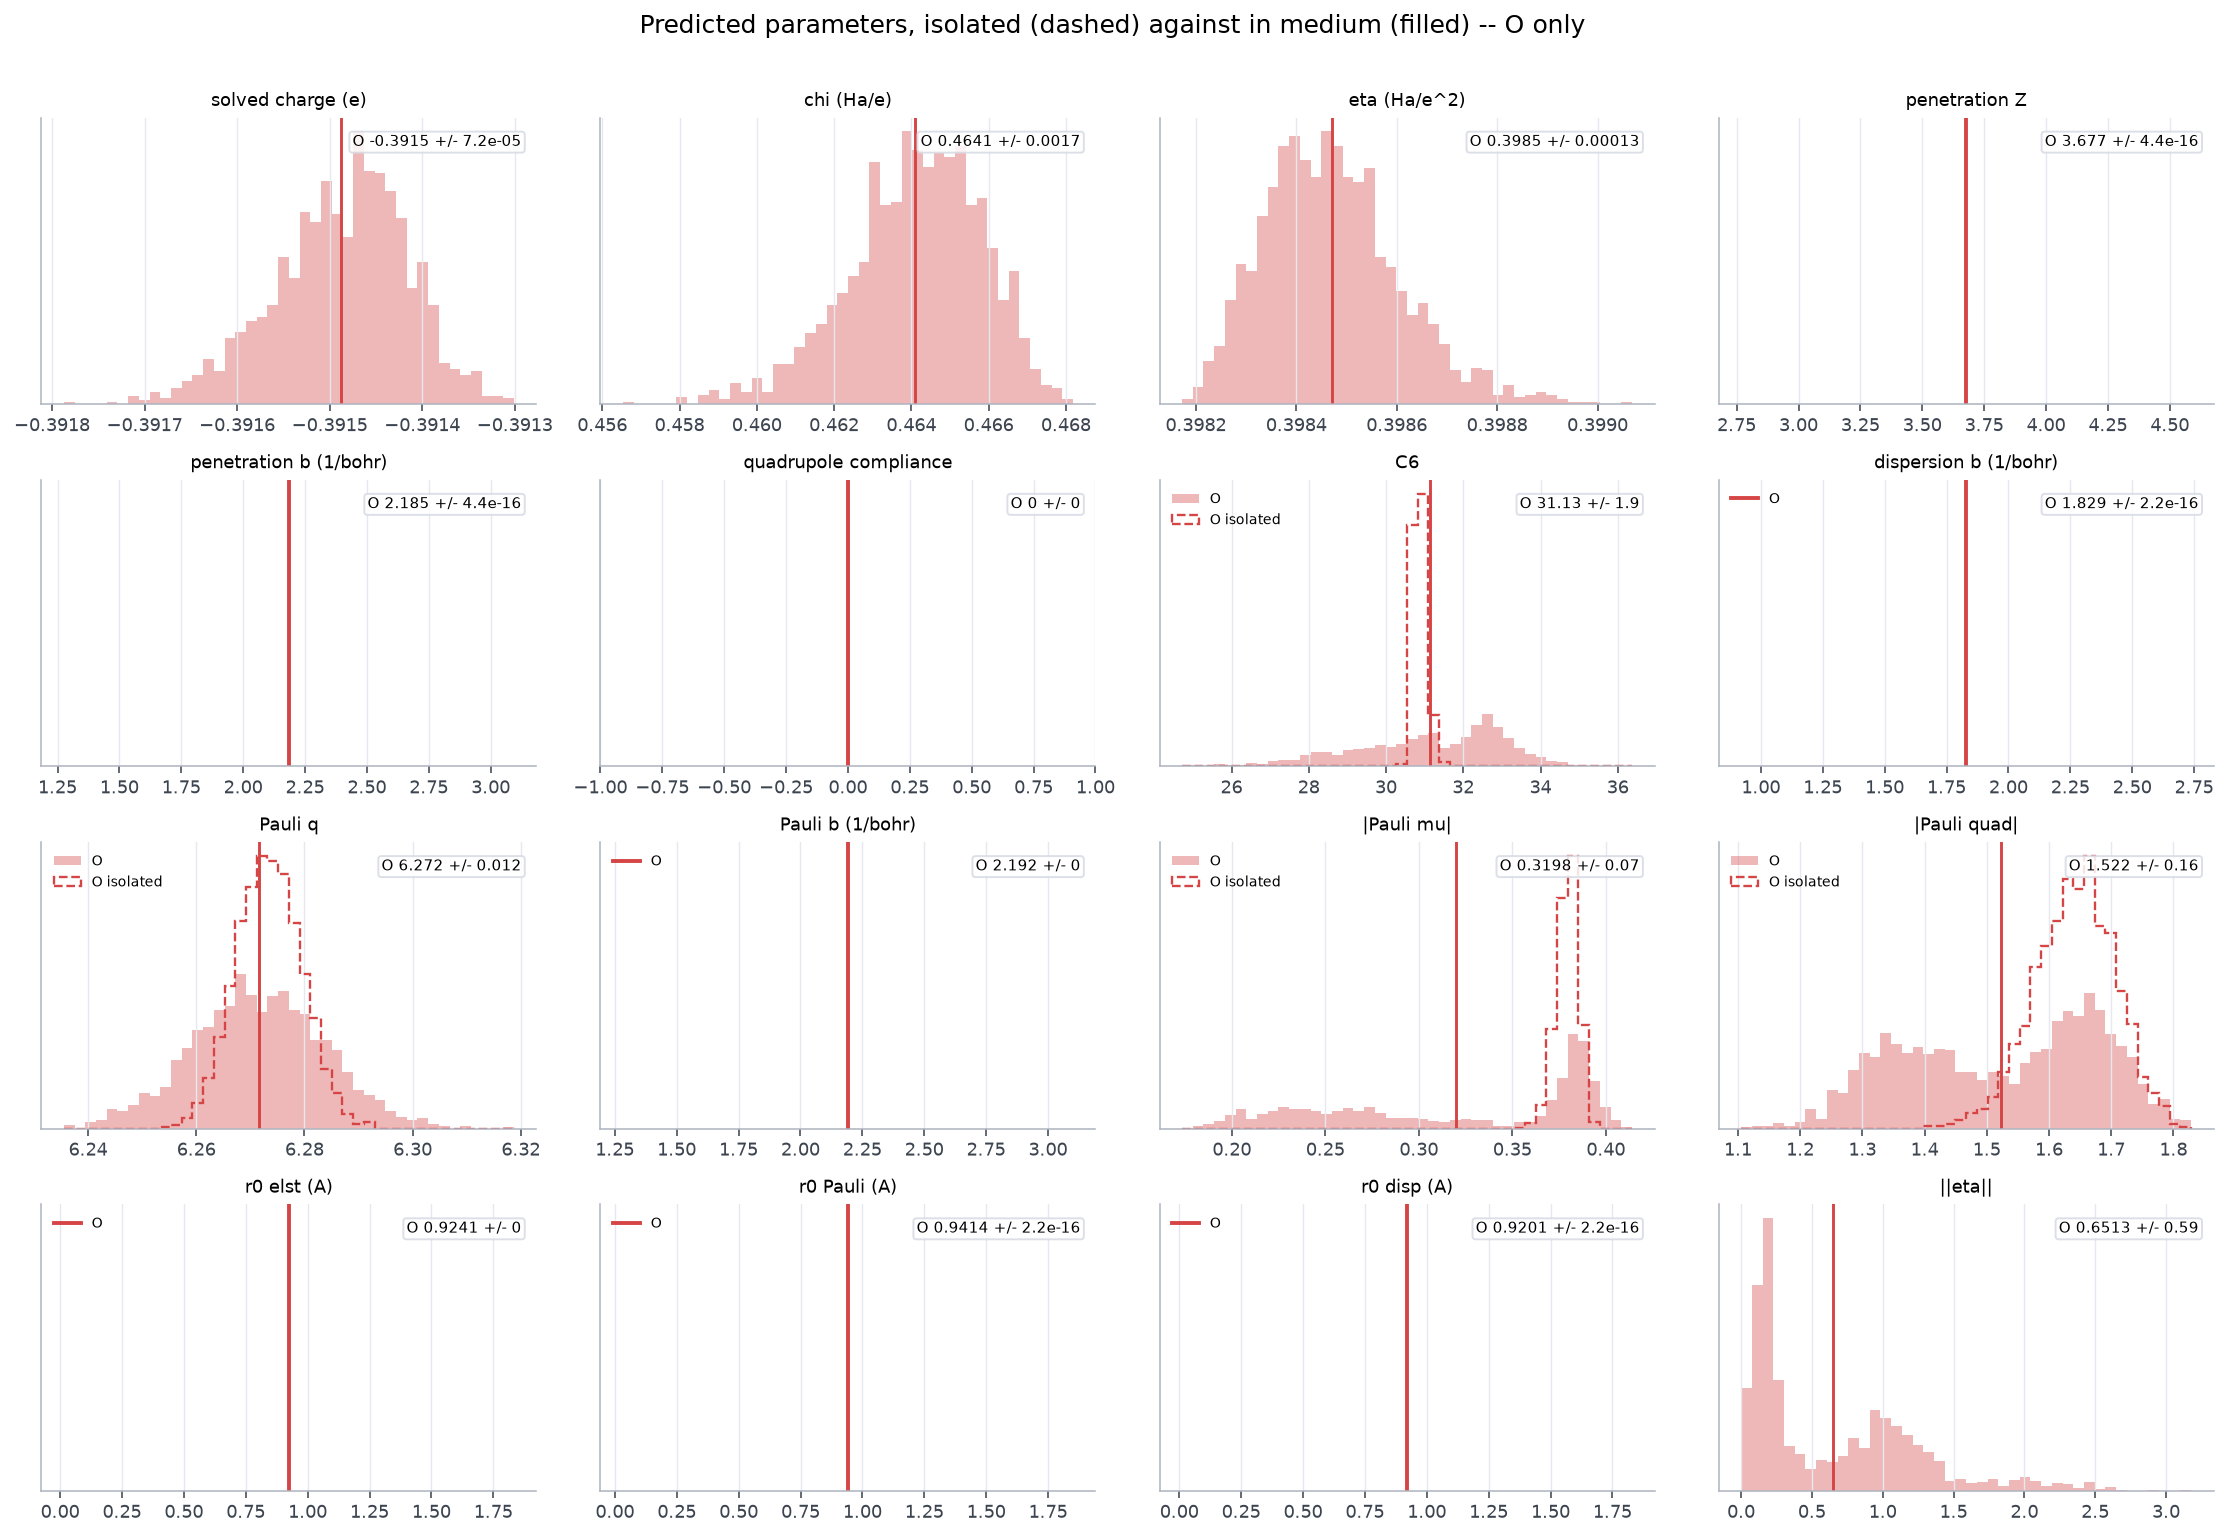

In [18]:
PARAM_SPECS = [
    ("q", "solved charge (e)"),
    ("chi", "chi (Ha/e)"),
    ("eta", "eta (Ha/e^2)"),
    ("z_pen", "penetration Z"),
    ("b_pen", "penetration b (1/bohr)"),
    ("cquad", "quadrupole compliance"),
    ("c6", "C6"),
    ("b_disp", "dispersion b (1/bohr)"),
    ("q_pauli", "Pauli q"),
    ("b_pauli", "Pauli b (1/bohr)"),
    ("mu_pauli", "|Pauli mu|"),
    ("quad_pauli", "|Pauli quad|"),
    ("r0_elst", "r0 elst (A)"),
    ("r0_pauli", "r0 Pauli (A)"),
    ("r0_disp", "r0 disp (A)"),
    ("env_norm", "||eta||"),
]


def plot_parameter_distributions(params, z=None, path=None, ncols=4):
    """One panel per parameter; `z` restricts to a single element.

    Where a parameter has both evaluations, the **isolated** distribution is drawn as an
    outline and the **in-medium** one filled. The gap between them is what the environment
    slot is doing to that parameter, and it is the same quantity `env_c6` and friends report
    in the training log -- here resolved per atom instead of averaged.

    Split by element because the two are not on the same scale: C6 is ~2 on H and ~37 on O, so
    a shared axis draws H as a spike at the origin and hides its whole distribution.
    """
    mask = np.ones(len(params["Z"]), bool) if z is None else (params["Z"] == z)
    zs = sorted(set(params["Z"][mask]))
    nrows = int(np.ceil(len(PARAM_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, (key, label) in zip(axes.ravel(), PARAM_SPECS):
        ax.set_visible(True)
        iso_key = f"{key}_iso" if f"{key}_iso" in params else None
        for zi in zs:
            sel = mask & (params["Z"] == zi)
            vals = params[key][sel]
            if len(vals) == 0:
                continue
            color = ELEMENT_COLOR.get(int(zi), "#555")
            name = ELEMENT.get(int(zi), str(zi))
            if float(vals.max() - vals.min()) <= 1e-12:
                # A per-element constant -- every `r0` while `environment_r0` is off, and any
                # head whose `environment_*` switch is false. A histogram of one value is a
                # single bin of meaningless height, so draw the value instead. Seeing which
                # panels are lines rather than distributions is itself the readout.
                ax.axvline(float(vals[0]), color=color, lw=2.0, label=name)
                ax.set_xlim(float(vals[0]) - 1.0, float(vals[0]) + 1.0)
                continue
            bins = np.histogram_bin_edges(vals, bins=42)
            ax.hist(vals, bins=bins, density=True, histtype="stepfilled", alpha=0.38,
                    color=color, label=name)
            ax.axvline(vals.mean(), color=color, lw=1.5)
            if iso_key is not None:
                iso_vals = params[iso_key][sel]
                if not np.allclose(iso_vals, vals):
                    ax.hist(iso_vals, bins=bins, density=True, histtype="step",
                            color=color, lw=1.2, ls="--",
                            label=f"{name} isolated" if zi == zs[0] else None)
        summary = "\n".join(
            f"{ELEMENT.get(int(zi), zi)} {params[key][mask & (params['Z'] == zi)].mean():.4g}"
            f" +/- {params[key][mask & (params['Z'] == zi)].std():.2g}" for zi in zs
        )
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
        if iso_key is not None and ax.get_legend_handles_labels()[1]:
            ax.legend(frameon=False, fontsize=7)
    who = "all elements" if z is None else f"{ELEMENT.get(int(z), z)} only"
    fig.suptitle(
        f"Predicted parameters, isolated (dashed) against in medium (filled) -- {who}",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


for z in sorted(set(params["Z"])):
    name = ELEMENT.get(int(z), str(int(z)))
    fig = plot_parameter_distributions(
        params, z=int(z),
        path=FIGDIR / f"{FIGPREFIX}_parameter_distributions_{name}.png",
    )
    plt.show()


In [19]:
class EnergyTermModel(torch.nn.Module):
    def __init__(self, model, term):
        super().__init__()
        self.model = model
        self.term = term

    def forward(self, batch):
        out = self.model(batch)
        if self.term == "total":
            # For the MBE plot, the total binding contribution beyond pairwise is the
            # interaction sum. One-body deformation cancels only if singleton terms are
            # included; this helper's convention is E(singleton) = 0.
            energy = out.energy.new_zeros(out.energy.shape)
            for value in out.interaction.values():
                energy = energy + value
        elif self.term == "onebody":
            energy = pool_fragments_to_frames(out.fragment_energy, batch)
        else:
            energy = out.interaction[self.term]
        return SimpleNamespace(energy=energy)


def strongest_indices(dataset, n, key=MBE_SORT_KEY):
    batch = dataset.flat_batch(range(len(dataset)))
    if batch.eda is not None and key in batch.eda:
        values = to_np(batch.eda[key])
    else:
        values = to_np(batch.energy)
    return np.argsort(values)[:min(n, len(values))].tolist()


def collect_many_body_by_term(model, datasets, terms=None, per_cluster=MBE_PER_CLUSTER):
    if terms is None:
        terms = ["elst", "pauli", "disp"]
        if model.induction:
            terms.append("induction")
        terms.append("total")
    rows = []
    for term in terms:
        if term != "total" and term not in model.classical and term not in ("induction", "onebody"):
            continue
        wrapped = EnergyTermModel(model, term).to(next(model.parameters()).device)
        for tag in [t for t in ("w3", "w4", "w5") if t in datasets]:
            ds = datasets[tag]
            idx = strongest_indices(ds, per_cluster)
            res = mbe_dataset(wrapped, ds, idx, split_components=False, progress_every=0)
            k = KJMOL_PER_HARTREE
            for i in range(len(idx)):
                row = {
                    "term": term,
                    "tag": tag,
                    "n_fragments": int(res.n_fragments[i]),
                    "total": float(res.total[i]) * k,
                    "two_body": float(res.two_body[i]) * k,
                    "many_body": float(res.many_body[i]) * k,
                }
                for order in (3, 4, 5):
                    vals = res.by_order.get(order)
                    row[f"e{order}"] = float(vals[i]) * k if vals is not None else 0.0
                rows.append(row)
    return rows


mbe_rows = collect_many_body_by_term(model, datasets)
print(f"many-body rows: {len(mbe_rows)}")
for term in sorted({r['term'] for r in mbe_rows}):
    vals = np.array([r["many_body"] for r in mbe_rows if r["term"] == term])
    print(f"{term:<8} mean={vals.mean():>9.4f} kJ/mol   mean abs={np.abs(vals).mean():>9.4f}")

many-body rows: 600
disp     mean=   0.4082 kJ/mol   mean abs=   0.4158
elst     mean=   0.0000 kJ/mol   mean abs=   0.0000
induction mean= -11.8023 kJ/mol   mean abs=  11.8023
pauli    mean=  -0.3822 kJ/mol   mean abs=   0.4552
total    mean= -11.7763 kJ/mol   mean abs=  11.7763


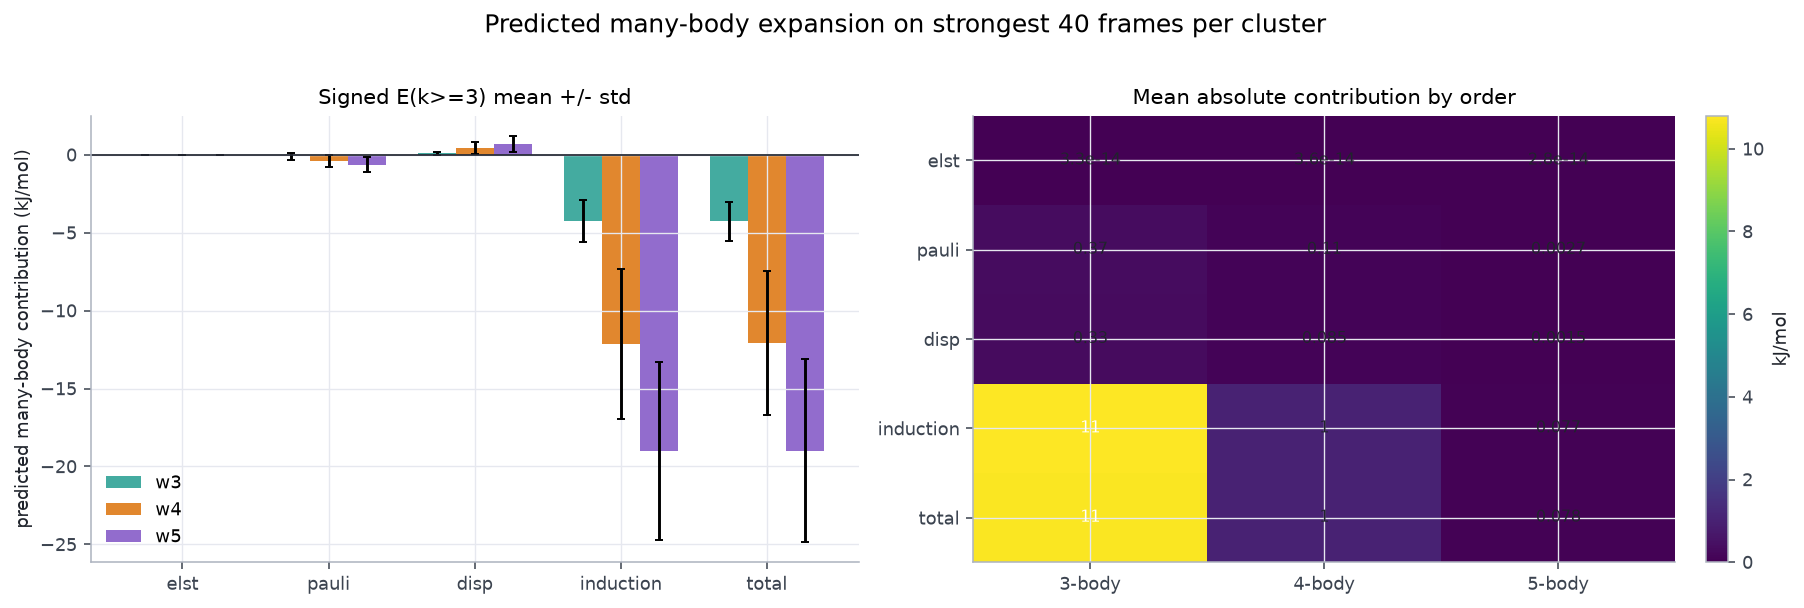

In [20]:
def plot_many_body(rows, path=None):
    terms = [t for t in ["elst", "pauli", "disp", "induction", "total"] if any(r["term"] == t for r in rows)]
    tags = [t for t in ["w3", "w4", "w5"] if any(r["tag"] == t for r in rows)]
    x = np.arange(len(terms))
    width = 0.78 / max(1, len(tags))
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))

    ax = axes[0]
    for j, tag in enumerate(tags):
        means, stds = [], []
        for term in terms:
            vals = np.array([r["many_body"] for r in rows if r["term"] == term and r["tag"] == tag])
            means.append(np.mean(vals) if len(vals) else 0.0)
            stds.append(np.std(vals) if len(vals) else 0.0)
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, means, width=width,
               yerr=stds, capsize=2, color=PALETTE.get(tag, "#555"), alpha=0.82, label=tag)
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(terms)
    ax.set_ylabel("predicted many-body contribution (kJ/mol)")
    ax.set_title("Signed E(k>=3) mean +/- std")
    ax.legend(frameon=False)

    ax = axes[1]
    orders = ["e3", "e4", "e5"]
    image = np.zeros((len(terms), len(orders)))
    for i, term in enumerate(terms):
        for j, order in enumerate(orders):
            vals = np.array([r[order] for r in rows if r["term"] == term])
            image[i, j] = np.mean(np.abs(vals)) if len(vals) else 0.0
    im = ax.imshow(image, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xticks(np.arange(len(orders)))
    ax.set_xticklabels(["3-body", "4-body", "5-body"])
    ax.set_title("Mean absolute contribution by order")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("kJ/mol")
    for i in range(len(terms)):
        for j in range(len(orders)):
            ax.text(j, i, f"{image[i, j]:.2g}", ha="center", va="center",
                    color="white" if image[i, j] > image.max() * 0.45 else "#20242c", fontsize=8)

    fig.suptitle(f"Predicted many-body expansion on strongest {MBE_PER_CLUSTER} frames per cluster", y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_many_body(mbe_rows, path=FIGDIR / f"{FIGPREFIX}_many_body_by_term.png")
plt.show()

In [21]:
def collect_force_predictions(model, datasets, cfg, device, n_frames=FORCE_FRAMES_PER_CLUSTER):
    ref_parts, pred_parts, tags = [], [], []
    for tag, ds in datasets.items():
        if not ds.has_forces:
            print(f"{tag}: no force labels; skipping")
            continue
        indices = frame_indices(ds, cfg)[:min(n_frames, len(ds))]
        for idx in indices:
            batch = ds.flat_batch([idx]).to(device)
            batch.positions.requires_grad_(True)
            out = model(batch)
            forces = compute_forces(out.energy, batch.positions, create_graph=False)
            ref = to_np(batch.forces) * KJMOL_PER_HARTREE
            pred = to_np(forces) * KJMOL_PER_HARTREE
            ref_parts.append(ref.reshape(-1))
            pred_parts.append(pred.reshape(-1))
            tags.extend([tag] * ref.size)
    return {
        "ref": np.concatenate(ref_parts),
        "pred": np.concatenate(pred_parts),
        "tag": np.asarray(tags),
    }


forces = collect_force_predictions(model, datasets, cfg, device)
mae, rmse, r2 = metrics(forces["ref"], forces["pred"])
print(f"force components: n={len(forces['ref'])}  MAE={mae:.5g}  RMSE={rmse:.5g}  R2={r2:.5f}  unit=kJ/mol/A")

force components: n=5040  MAE=3.2188  RMSE=4.4877  R2=0.99669  unit=kJ/mol/A


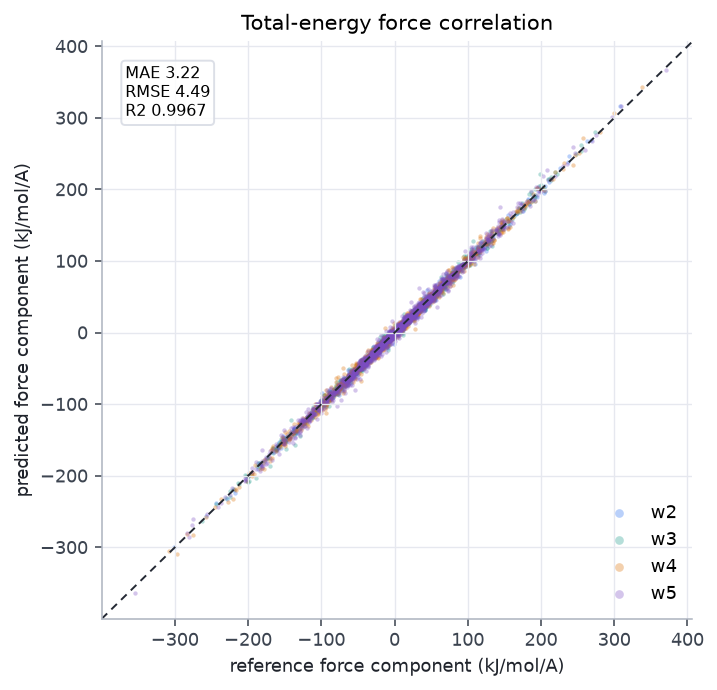

In [22]:
def plot_force_correlation(forces, path=None):
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ref, pred, tags = forces["ref"], forces["pred"], forces["tag"]
    lo = min(ref.min(), pred.min())
    hi = max(ref.max(), pred.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
    for tag in sorted(set(tags)):
        m = tags == tag
        ax.scatter(ref[m], pred[m], s=5, alpha=0.32, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
    mae, rmse, r2 = metrics(ref, pred)
    ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("reference force component (kJ/mol/A)")
    ax.set_ylabel("predicted force component (kJ/mol/A)")
    ax.set_title("Total-energy force correlation")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.legend(frameon=False, markerscale=2)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_force_correlation(forces, path=FIGDIR / f"{FIGPREFIX}_force_correlation.png")
plt.show()

## Notes

- To regenerate these diagnostics for a different model, edit `CHECKPOINT` at the top. The
  model is rebuilt from the config the checkpoint carries, so there is no stage to select and
  no way for the notebook to build something other than what the weights came from. Figure
  names follow the checkpoint directory, so two runs do not overwrite each other.
- **The isolated/environment split is the notebook's main new readout.** `iso` is every channel
  evaluated with the environment weights zeroed -- what the model would say if each fragment
  were alone -- and `env` is the remainder. `elst` must show `env = 0`: `eda_cls_elec` is the
  Coulomb interaction between superimposed frozen monomer densities and is rigorously pairwise,
  so its parameters read `theta_0` by construction. Pauli and dispersion should not be zero;
  that is their many-body content.
- Read panel (b) for *how* the environment share behaves with cluster size. A share that grows
  from w2 to w5 is real many-body physics. A share already large on w2 -- where there is none to
  find -- means the environment slot is doing two-body work that belongs in `theta_0`, and
  `expert.env_penalty_weight` is the dial for that.
- The one-body sector has no environment share at all, and the split cell **asserts** it rather
  than plotting it: `fragment_energy` reads `theta_0` everywhere, so zeroing every environment
  weight must leave it bitwise unchanged. If that assertion ever fires, every isolated number
  here is meaningless and the routing has a leak.
- `induction` is one channel fitted against `eda_pol + eda_ct`. Its `param half` column is
  `energy_bond_ind - energy_bond_ind_iso`: the part carried by re-reading the bonding energy at
  the in-medium parameters rather than by the coupled solve relaxing the multipoles. Both are
  physical -- the environment-dependence of bonding *is* the charge-transfer mechanism here --
  but if it is most of `env` while the solve contributes nothing, induction has become a
  network wearing the label. Two earlier charge-transfer channels failed exactly that way.
- Parameter panels draw the isolated distribution dashed and the in-medium one filled. A panel
  where the two coincide is a parameter with no environment dependence, which for `b_disp`,
  `b_pauli` and every `r0` is a config choice (`environment_b`, `environment_r0` are off), not
  a fitted result.
- Monomer deformation and cluster binding energies use `REFERENCE_SPECIES` from
  `ISOLATED_SPECIES_REFERENCE` as the zero of energy. The same constant is subtracted from the
  reference and the prediction, so it shifts both axes and not the residuals.
